# Hybrid framework DQN-v3 - Training

In [3]:
import os
import io
import random
import math
import torch
import json
import pickle
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter
from ultralytics import YOLO 
import torch.nn.functional as F
from tqdm import tqdm
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import probtools
from mylib import dqn_v3
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import NUM_CLASSES, DIRICHLET_PRIOR
from constants import ACTIONS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

In [4]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration 
simulation = simulations[52] # 53 or 54 would be the same; 55 test
 
# Access its fields
SCENE = simulation["scene"]
# TARGET_OBJECT = simulation["target_object"]
# TARGET_OBJECT_ID = simulation["target_object_id"]
# REAL_TARGET_LOCATION = simulation["target_object_location"]
# INDEX = simulation["index"]

TARGET_OBJECTS = ["teddy bear", "potted plant", "laptop"]
TARGET_OBJECT_IDS = [77, 58, 63]
REAL_TARGET_LOCATIONS = [[-9.09979248046875,0.3305816948413849,-2.410083532333374],
                         [-4.789992809295654,0.5929855108261108,-1.260035514831543],
                         [-1.3711198568344116,0.814714252948761,-3.8145105838775635]]
INDEXES = [52, 53, 54]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Load bins per class
with open('simulation-data/object-classes-bins.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor-objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]

#TARGET_OBJECT_CLASS_ID = indoor_objects.index(TARGET_OBJECT)
TARGET_OBJECT_CLASS_IDS = [indoor_objects.index(obj) for obj in TARGET_OBJECTS]

# Load Dirichlet priors
with open('simulation-data/dirichlet-alpha-priors-augmented.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.230.02
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[12:48:06:223623]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/RoboTHOR/FloorPlan_Train3_1.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
[12:48:06:484216]:[Warning]:[Sim

In [5]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free and occupied cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
grid_occ_cells, map_occ_cells, world_occ_coords = myutils.find_occupied_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)

# Merge free and occupied positions into a single list
grid_cells = grid_free_cells + grid_occ_cells
map_cells = map_free_cells + map_occ_cells
world_coords = world_free_coords + world_occ_coords

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

# Build binary int grid map (0: free, 1: occupied)
grid_binary_map = np.zeros_like(grid_map, dtype=np.int32)
# Filter out-of-bounds cells
valid_occ_cells = [
	(x, y) for (x, y) in grid_occ_cells
	if 0 <= x < grid_binary_map.shape[0] and 0 <= y < grid_binary_map.shape[1]
]
grid_binary_map[tuple(np.array(valid_occ_cells).T)] = 1
grid_binary_map = grid_binary_map[..., 0] 

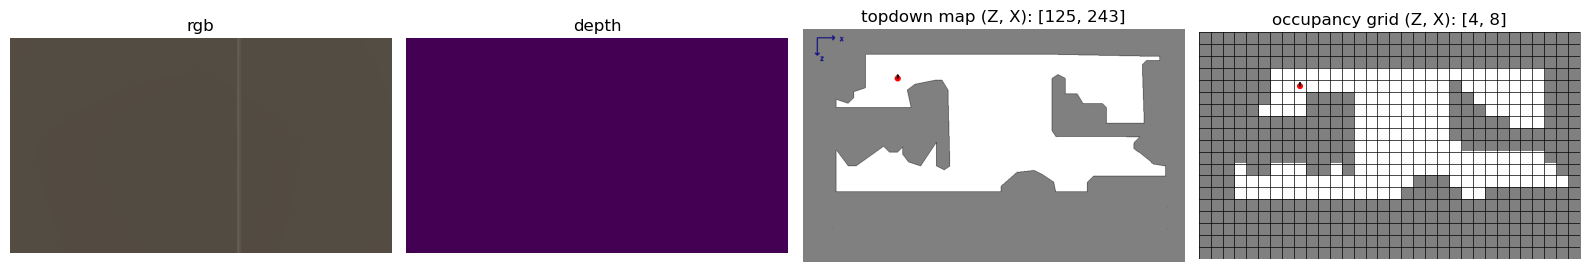

In [6]:
# Initialize belief map: NUM_CLASSES + 1 for the background 
belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_free_cells)
idx = grid_free_cells.index(grid_position)
world_position = world_free_coords[idx]
map_position = map_free_cells[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = world_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius = (topdown_radius, grid_radius)
agent_positions = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb, depth = observations["color_sensor"], observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

In [ ]:
# Hyperparameters
gamma = 0.99
batch_size = 128
lr = 1e-3
target_update_freq = 2000 #steps
max_episodes = 500
buffer_capacity = 50_000
load_pretrained = True  # Set to False to train from scratch

# Counters
global_step = 0
turn_right_actions = 0
turn_left_actions = 0
move_forward_actions = 0
teddy_bear_count = 0
teddy_bear_found = 0
potted_plant_count = 0
potted_plant_found = 0
laptop_count = 0
laptop_found = 0

# Simulation parameters
NUM_ACTIONS = len(ACTIONS)  # Number of actions available
MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform

# Initialize DQN + target network
policy_net = dqn_v3.ObjectSearchQNetwork(in_channels=6, num_actions=NUM_ACTIONS).to(device)
target_net = dqn_v3.ObjectSearchQNetwork(in_channels=6, num_actions=NUM_ACTIONS).to(device)
dqn_v3.hard_update_target(policy_net, target_net)

# Load from file if exists
if load_pretrained and os.path.exists("dqn_policy_v3.pth"):
    policy_net.load_state_dict(torch.load("dqn_policy_v3.pth"))
    print("Loaded pretrained model from dqn_policy_v3.pth")

# Initialize target network based on policy_net
target_net.load_state_dict(policy_net.state_dict())

# Initialize optimizer and replay buffer
optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
replay = dqn_v3.ReplayBuffer(capacity=buffer_capacity, device=device)

# ε schedule
eps_start, eps_end, eps_decay_episodes = 0.2, 0.05, 0.8 * max_episodes
def epsilon_for(ep):
    # exponential decay over 80% of training
    k = -np.log(eps_end/eps_start) / max(1, eps_decay_episodes)
    return eps_end + (eps_start - eps_end) * np.exp(-k * ep)

# # Plot the epsilon_for function
# x = np.arange(0, max_episodes, 1)
# y = epsilon_for(x)
# plt.figure(figsize=(10, 5))
# plt.plot(x, y, label='Epsilon Decay', color='blue')
# plt.title('Epsilon Decay Over Episodes')
# plt.xlabel('Episode')
# plt.ylabel('Epsilon')
# plt.legend()
# plt.grid()
# plt.show()

# Track losses
losses = []

# Track performance
episode_lengths = []
episode_location_errors = []
episode_travelled_distances = []
episode_success_flags = []  
episode_rewards = []

# Main training loop
for episode in tqdm(range(max_episodes)):

    # Selection of the target object for this episode
    episode_idx = random.randint(0, len(TARGET_OBJECTS)-1)
    TARGET_OBJECT = TARGET_OBJECTS[episode_idx]
    TARGET_OBJECT_ID = TARGET_OBJECT_IDS[episode_idx]
    REAL_TARGET_LOCATION = REAL_TARGET_LOCATIONS[episode_idx]
    INDEX = INDEXES[episode_idx]
    TARGET_OBJECT_CLASS_ID = TARGET_OBJECT_CLASS_IDS[episode_idx]
    target_grid_position = None

    # Increment object counters
    if TARGET_OBJECT == "teddy bear":
        teddy_bear_count += 1
    elif TARGET_OBJECT == "potted plant":
        potted_plant_count += 1
    elif TARGET_OBJECT == "laptop":
        laptop_count += 1
    
    # Metrics init
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")
    episode_reward = 0.0

    # Get epsilon for exploration
    epsilon = epsilon_for(episode)

    # Set belief map
    belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

    # Init reward computation variables
    prev_target_prob = dqn_v3.compute_max_target_prob(belief_map, grid_binary_map, TARGET_OBJECT_CLASS_ID)
    prev_entropy = dqn_v3.compute_entropy_patch(belief_map, grid_binary_map, grid_position)

    # Init agent state
    grid_position = random.choice(grid_free_cells)
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]
    agent_positions = (map_position, grid_position)

    agent_yaw = random.choice([0, 90, 180, 270])
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Set observations
    state = dqn_v3.build_fullmap_obs(
        np.array(np.array(belief_map, dtype=np.float32)), 
        TARGET_OBJECT_CLASS_ID, 
        grid_binary_map, 
        tuple(grid_position), 
        math.radians(agent_yaw), 
        NUM_CLASSES+1
    )

    # Run episode
    while not target_found and num_actions < MAX_ITER:

        # Select action using epsilon-greedy 
        action = dqn_v3.select_action(policy_net, state, epsilon, NUM_ACTIONS)
        action_str = list(ACTIONS)[action]

        # # Print action to debug
        # print(f"Action selected: {action_str}")

        # Add action to counters
        if action_str == "turn_right":
            turn_right_actions += 1
        elif action_str == "turn_left":
            turn_left_actions += 1
        elif action_str == "move_forward":  
            move_forward_actions += 1

        # Perform action if valid
        if simtools.is_action_valid(action_str, grid_position, agent_yaw, grid_free_cells):
            grid_position, agent_yaw = simtools.perform_action(action_str, grid_position, agent_yaw)

        # Update agent position and state
        idx = grid_free_cells.index(grid_position)
        map_position, world_position = map_free_cells[idx], world_free_coords[idx]
        agent_positions = (map_position, grid_position)
        agent_quart = myutils.yaw_to_quaternion(agent_yaw)

        # Update metrics
        num_actions += 1
        travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

        # Update agent state
        agent_state.position = world_position
        agent_state.rotation = agent_quart
        agent.set_state(agent_state)

        # Get observations
        obs = sim.get_sensor_observations(0)
        rgb, depth = obs["color_sensor"], obs["depth_sensor"]

        # YOLO Prediction
        results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
        detections = simtools.parse_yolo_detections(results)
        simtools.merge_rgb_yolo_outputs(rgb, detections)
        target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
        
        # Initialize processed cells
        processed_cells = []

        # Process the observations
        for det in detections:
            box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
            scale = myutils.compute_bbox_scale(box, rgb)

            # Center of bbox and depth value
            center_x, center_y = simtools.get_box_center(box)
            depth_value = depth[center_y, center_x]

            # Project to real world, grid and map coords
            camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
            object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
            object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

            # Check if projected cell is outside free grid cells
            if object_grid_position in grid_free_cells:
                object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

            # Add this cell to processed cells
            if tuple(object_grid_position) not in processed_cells:
                processed_cells.append(tuple(object_grid_position))

            # Likelihood vector: likelihood of each class (Rule 1)
            likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

            # Kaplan Update to the belief map in that cell
            grid_x, grid_y = object_grid_position
            belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

        # Compute every theoretically visible occupied cell
        rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
        visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)
        
        # Go through every visible occupied cell and update the belief map
        for cell in visible_occ_cells:
            if tuple(cell) not in processed_cells:
                # Compute distance to the cell
                grid_x, grid_y = cell
                distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                # Compute the likelihood vector for the cell (Rule 2)
                likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                # Kaplan update to the belief map in that cell
                belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

        # Check if the target object was found in the belief map
        if not target_found:
            target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD)

        # Compute the target location if it was found
        if target_found:

            if target_grid_position is None: # Not found in the belief map
                # Real world position
                center_x, center_y = simtools.get_box_center(target_bbox)
                depth_value = depth[center_y, center_x]
                target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)
            else:
                # Real world position from grid position
                target_location = world_coords[grid_cells.index(target_grid_position)]

        # Evaluating correctness of the target detection
        if target_found:
            # Location error
            location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

            # Compare with threshold
            if location_error > LOCATION_ERROR_THRESHOLD:
                target_found = False

        # Compute reward
        curr_entropy = dqn_v3.compute_entropy_patch(belief_map, grid_binary_map, grid_position)
        curr_target_prob = dqn_v3.compute_max_target_prob(belief_map, grid_binary_map, TARGET_OBJECT_CLASS_ID)
        reward = dqn_v3.compute_reward_two(target_found, prev_entropy, curr_entropy, prev_target_prob, curr_target_prob)

        # Compute next observation
        next_state = dqn_v3.build_fullmap_obs(
            np.array(np.array(belief_map, dtype=np.float32)), 
            TARGET_OBJECT_CLASS_ID, 
            grid_binary_map, 
            tuple(grid_position), 
            math.radians(agent_yaw), 
            NUM_CLASSES+1
        )

        # Print reward to debug
        # print(f"Current entropy: {curr_entropy:.4f}, previous entropy: {prev_entropy:.4f}")
        # print(f"Current target prob: {curr_target_prob:.4f}, previous target prob: {prev_target_prob:.4f}")
        # print(f"Reward received: {reward}")
        # simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

        # Is it done?
        done = target_found or num_actions >= MAX_ITER
        prev_entropy = curr_entropy
        prev_target_prob = curr_target_prob

        # Store transition
        replay.push(state, action, reward, next_state, float(done))

        # Train the policy DQN
        if len(replay) >= batch_size:
            # train
            loss = dqn_v3.dqn_update(policy_net, target_net, optimizer, replay, batch_size=batch_size, gamma=gamma)
            losses.append(loss)

        # target update
        global_step += 1
        if global_step % target_update_freq == 0:
            dqn_v3.hard_update_target(policy_net, target_net)

        state = next_state
        episode_reward += reward


    # Display simulation result and metrics
    # if target_found:
    #     print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
    #     print(f"Found location: {target_location}")
    # else:
    #     print(f"\nTarget object <{TARGET_OBJECT}> not found after {num_actions} actions!")

    # print(f"Ground-truth location: {REAL_TARGET_LOCATION}")
    # print(f"Number of actions: {num_actions}")
    # print(f"Travelled distance: {travelled_distance:.2f} m")
    # print(f"Computed location error: {location_error:.3f} m")

    # print(f"Turn right actions: {turn_right_actions} ({turn_right_actions/num_actions*100:.2f}%)")
    # print(f"Turn left actions: {turn_left_actions} ({turn_left_actions/num_actions*100:.2f}%)")
    # print(f"Move forward actions: {move_forward_actions} ({move_forward_actions/num_actions*100:.2f}%)")

    # print(f"Episode reward: {episode_reward:.2f}")

    # simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

    # Update found counters
    if target_found:
        if TARGET_OBJECT == "teddy bear":
            teddy_bear_found += 1
        elif TARGET_OBJECT == "potted plant":
            potted_plant_found += 1
        elif TARGET_OBJECT == "laptop":
            laptop_found += 1

    # Append metrics
    episode_lengths.append(num_actions)
    episode_location_errors.append(location_error)
    episode_travelled_distances.append(travelled_distance)
    episode_success_flags.append(target_found)
    episode_rewards.append(episode_reward)

# After training, save the model
# torch.save(policy_net.state_dict(), "dqn_policy_v3.pth")

Loaded pretrained model from dqn_policy_v3.pth


100%|██████████| 3000/3000 [6:57:32<00:00,  8.35s/it]  


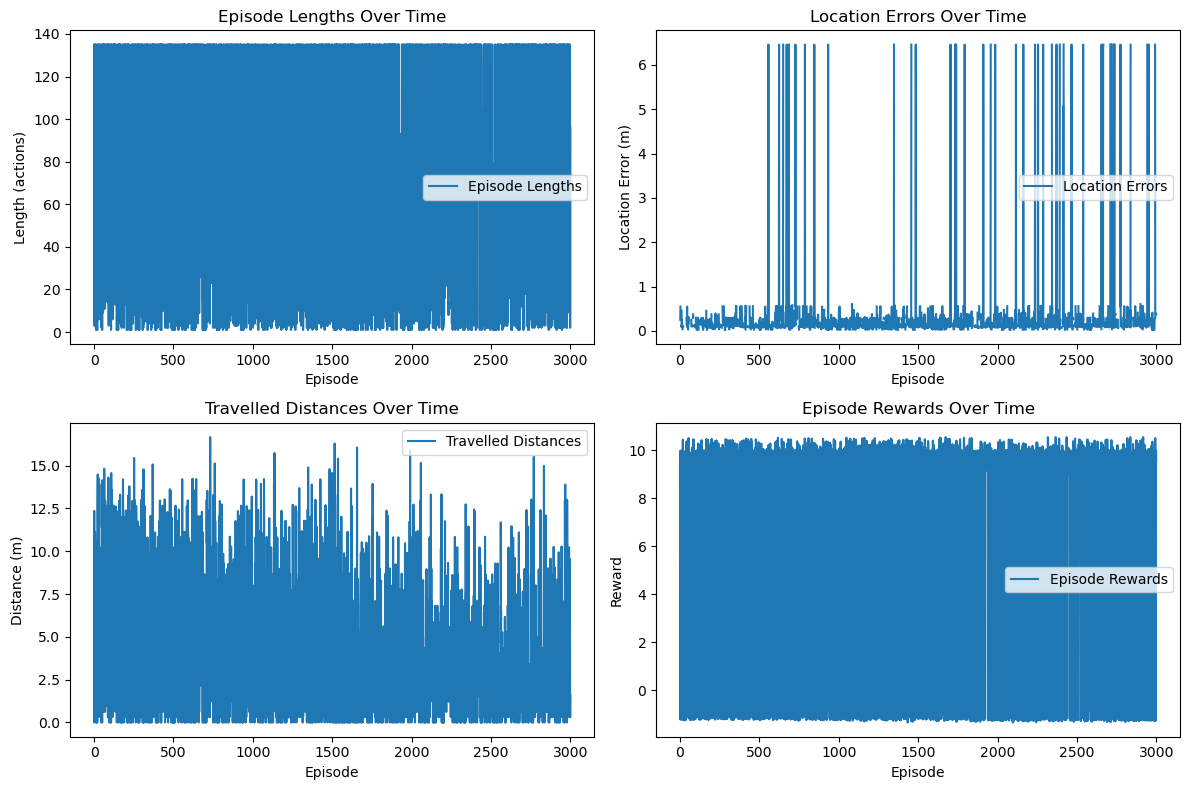

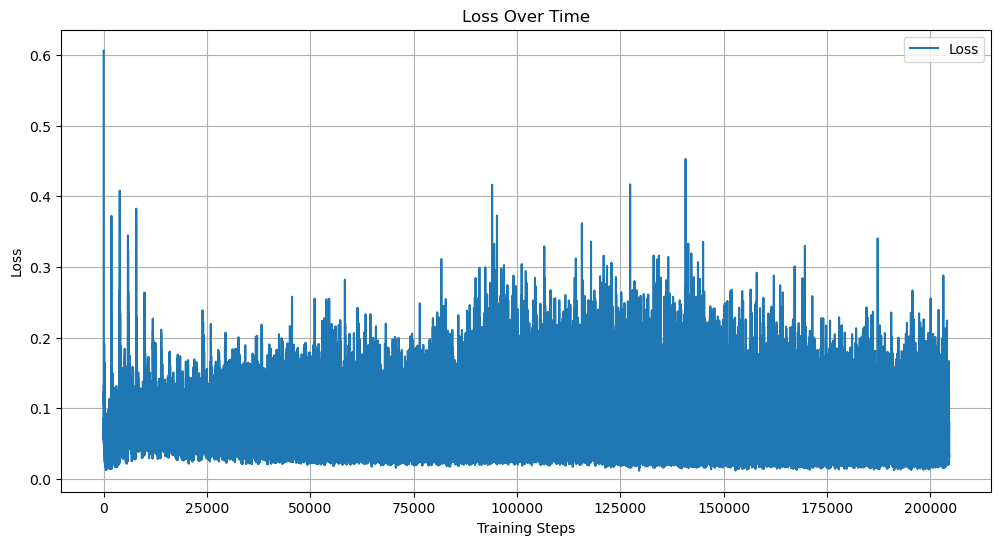

In [35]:
# Plot learning curves
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(episode_lengths, label='Episode Lengths')
plt.xlabel('Episode')
plt.ylabel('Length (actions)')
plt.title('Episode Lengths Over Time')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(episode_location_errors, label='Location Errors')
plt.xlabel('Episode')
plt.ylabel('Location Error (m)')
plt.title('Location Errors Over Time')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(episode_travelled_distances, label='Travelled Distances')
plt.xlabel('Episode')
plt.ylabel('Distance (m)')
plt.title('Travelled Distances Over Time')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(episode_rewards, label='Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Episode Rewards Over Time')
plt.legend()
plt.tight_layout()
plt.show()

# Plot loss curve
plt.figure(figsize=(12, 6))
plt.plot(losses, label='Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Loss Over Time')
plt.legend()
plt.grid()
plt.show()


In [36]:
# Print final statistics
print(f"\n\nFinal Statistics after {max_episodes} episodes:")
print(f"Total actions taken: {sum(episode_lengths)}")
print(f"Total target found: {sum(episode_success_flags)}")
print(f"Average episode length: {np.mean(episode_lengths):.2f} actions")
print(f"Average location error: {np.mean(episode_location_errors):.3f} m")
print(f"Average travelled distance: {np.mean(episode_travelled_distances):.2f} m")
print(f"Average episode reward: {np.mean(episode_rewards):.2f}")
print(f"Turn right actions: {turn_right_actions}")
print(f"Turn left actions: {turn_left_actions}")
print(f"Move forward actions: {move_forward_actions}")  
print(f"Sucess rate: {np.mean(episode_success_flags)*100:.2f}%")

# Print object-specific statistics
print(f"\nObject-specific statistics:")
print(f"Teddy bear - Count: {teddy_bear_count}, Found: {teddy_bear_found}, Success Rate: {(teddy_bear_found/teddy_bear_count*100) if teddy_bear_count > 0 else 0:.2f}%")
print(f"Potted plant - Count: {potted_plant_count}, Found: {potted_plant_found}, Success Rate: {(potted_plant_found/potted_plant_count*100) if potted_plant_count > 0 else 0:.2f}%")
print(f"Laptop - Count: {laptop_count}, Found: {laptop_found}, Success Rate: {(laptop_found/laptop_count*100) if laptop_count > 0 else 0:.2f}%")



Final Statistics after 3000 episodes:
Total actions taken: 204635
Total target found: 1980
Average episode length: 68.21 actions
Average location error: inf m
Average travelled distance: 4.26 m
Average episode reward: 6.11
Turn right actions: 59595
Turn left actions: 59308
Move forward actions: 85732
Sucess rate: 66.00%

Object-specific statistics:
Teddy bear - Count: 1017, Found: 625, Success Rate: 61.46%
Potted plant - Count: 999, Found: 937, Success Rate: 93.79%
Laptop - Count: 984, Found: 418, Success Rate: 42.48%


In [37]:
# Save the trained model
torch.save(policy_net.state_dict(), "dqn_policy_v3.pth")

In [ ]:
sim.close()  # Close the simulator